<h1 style="text-align:center; color:green";> ISAT 449: Emerging Topics in Applied Data Science </h1>
<center>
<h2 style="text-aligh:center; color:green"> Allie Zombron and Kelsey Robertson </h2>


    
<img src="images/speech_emotions.png" width=300 height =300>
</center>

<h2 style="text-align:center; color:blue";> Mini-Project: How to Make a Speech Emotion Recognizer Using Python and Scikit-learn </h2>

<b/><font style="color:orange;"/> Building a Speech Emotion Recognition system that detects emotion from human speech tone using the Scikit-Learn library, Python and Librosa

### What is Speech Emotion Recognition?
Speech Emotion Recognition, abbreviated as SER, is the act of attempting to recognize human emotion and affective states from
speech. This is capitalizing on the fact that voice often reflects underlying emotion through tone and pitch. This is also the
phenomenon that animals like dogs and horses employ to be able to understand human emotion.
SER is tough because emotions are subjective and annotating audio is challenging

### What is librosa?
librosa is a Python library for analyzing audio and music. It has a flatter package layout, standardizes interfaces and names,
backwards compatibility, modular functions, and readable code. Further, in this Python mini-project, we demonstrate how to install
it (and a few other packages) with pip

### What is JupyterLab?
As you have seen, I use JupyterLab which is an open-source, web-based UI for Project Jupyter and it has all basic functionalities
of the Jupyter Notebook, like notebooks, terminals, text editors, file browsers, rich outputs, and more. However, it also provides
improved support for third party extensions. It comes bubdled with the Anaconda Data Science Framework if you want to try it out,
BUT you can just keep using your Jupyter Notebook and all wii be fine.

### Speech Emotion Recognition – Objective
To build a model to recognize emotion from speech using the librosa and sklearn libraries and the RAVDESS dataset.

### Speech Emotion Recognition – About the Python Mini Project
In this Python mini project, we will use the libraries librosa, soundfile, and scikit-learn (among others) to build a model using an
MLPClassifier. Our model will able to recognize emotion from sound files. We will load the data, extract features from it, then split
the dataset into training and testing sets. Then, we’ll initialize an MLPClassifier and train the model. Finally, after we are satisfied
with the accuracy of our model, we will test the model on a sound file generated by our voice!

### The Dataset
For this Python mini project, we’ll use the RAVDESS dataset; this is the Ryerson Audio-Visual Database of Emotional Speech and
Song dataset, and is free to download. This dataset has 7356 files rated by 247 individuals 10 times on emotional validity, intensity,
and genuineness. The entire dataset is 24.8GB from 24 actors, but we're going to work with a version that has lowered the sample
rate on all the files, and you can download it from Canvas.

### File Summary
In total, the RAVDESS collection includes 7356 files (2880+2024+1440+1012 files).

### File naming convention
Each of the 7356 RAVDESS files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 02-01-06-01-
02-01-12.mp4). These identifiers define the stimulus characteristics:

### **Filename identifiers**

- Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
- Vocal channel (01 = speech, 02 = song).
- Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
- Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
- Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
- Repetition (01 = 1st repetition, 02 = 2nd repetition).
- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

*Filename example: 02-01-06-01-02-01-12.mp4*

- Video-only (02)
- Speech (01)
- Fearful (06)
- Normal intensity (01)
- Statement "dogs" (02)
- 1st Repetition (01)
- 12th Actor (12)
- Female, as the actor ID number is even.

You can find more information on the file structure and filenames from Zenodo: Filename References
(https://zenodo.org/record/1188976#.X3KzGGhKhPa)

### **Prerequisites**
You will need to install the following libraries/packages (most of them using pip):
1. librosa
2. soundfile
3. pyaudio (do this from within Anaconda Navigator. Look under Not Installed)
4. numpy (you should already have this installed)
5. scikit-learn (you should already have this installed)

So, the command to install **ALL** would be (don't do this since you already have scikit-learn and numpy installed!):

**pip install** *librosa soundfile numpy scikit-learn pyaudio*

BUT 

After you install pyaudio using Anaconda Navigator, you should really only need to pip install the two libraries librosa and
soundfile from the terminal(see image below) with the command:

<b/><font style="color:red;"/> pip install *librosa soundfile pyaudio*

using_anaconda_terminal.png

If you run into issues installing librosa with pip, you can try it with conda.

The whole pipeline is as follows (same as any machine learning pipeline):

- Preparing the Dataset: Here, we download and convert the dataset to be suited for extraction.
- Loading the Dataset: This process is about loading the dataset in Python which involves extracting audio features, such as
obtaining different features such as power, pitch and vocal tract configuration from the speech signal, we will use librosa
library to do that.
- Training the Model: After we prepare and load the dataset, we simply train it on a suited sklearn model.
- Testing the Model: Measuring how good our model is doing.

**NOTE on the dataset and file structure**

<b/><font style="color:red;"/> BEFORE you begin coding, download, the dataset from canvas and extract it to your project folder. I have modified the
folder name in the zipped file so that it is easier to parse (see the file structure I used below).

<h4> <b> Let's import the dependencies </b></h4>

1. Import files

In [1]:
import matplotlib.pyplot as plt
import soundfile # to read audio file
import numpy as np
import librosa # to extract speech features
import glob
import os
import pickle # to save model after training
from sklearn.model_selection import train_test_split # for splitting training and testing
from sklearn.neural_network import MLPClassifier # multi-layer perceptron model
from sklearn.metrics import accuracy_score # to measure how good we are

2. Define a function extract_feature to extract the mfcc, chroma, and mel features from a sound file. This function takes 4 parameters- the file name and three Boolean parameters for the three features:

- **mfcc**: Mel Frequency Cepstral Coefficient, represents the short-term power spectrum of a sound
- **chroma**: Pertains to the 12 different pitch classes
- **mel**: Mel Spectrogram Frequency

Open the sound file with soundfile.SoundFile using with-as so it’s automatically closed once we’re done. Read from it and call it X.

Also, get the sample rate. If chroma is True, get the Short-Time Fourier Transform of X.

Let result be an empty numpy array. Now, for each feature of the three, if it exists, make a call to the corresponding function from
librosa.feature (eg- librosa.feature.mfcc for mfcc), and get the mean value. Call the function hstack() from numpy with result and
the feature value, and store this in result. hstack() stacks arrays in sequence horizontally (in a columnar fashion). Then, return the
result.

In [2]:
# Extract features (mfcc, chroma, mel) from a sound file
def extract_feature(file_name, mfcc, chroma, mel):
    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate=sound_file.samplerate
        if chroma:
            stft=np.abs(librosa.stft(X))
        result=np.array([])
        if mfcc:
            mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
            result=np.hstack((result, mfccs))
        if chroma:
            chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
            result=np.hstack((result, chroma))
        if mel:
            mel=np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result,mel))
    return result

3. Now, let’s define a dictionary to hold numbers and the emotions available in the RAVDESS dataset, and a list to hold those we want to use in our model- calm, happy, fearful, disgust.<font style="color:red;"/>  We are starting with four(4) emotions to observe but you MUST use six
(6) in your model!

In [3]:
# emotions in the RAVDESS dataset
emotions={
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

# emotions to observe
observed_emotions=['calm','happy','fearful','disgust','sad','angry']
# two emotions I added: sad and angry

4. Now, let’s load the data with a function load_data() – this takes in the relative size of the test set as parameter. x and y are
empty lists; we’ll use the glob() function from the glob module to get all the pathnames for the sound files in our dataset. The
pattern we use for this is: *“ravdess-data\Actor_\*.wav”. This is because our dataset looks like this:

In [4]:
# load the data and extract features for each sound file
def load_data(test_size=0.2):
    x,y=[],[]
    #for file in glob.glob("ravdess-data\\Actor_*\\*.wav"):
    for file in glob.glob("ravdess-data/Actor_*/*.wav"):
        file_name=os.path.basename(file)
        emotion=emotions[file_name.split("-")[2]]
        if emotion not in observed_emotions:
            continue
        feature=extract_feature(file, mfcc=True, chroma=True, mel=True)
        x.append(feature)
        y.append(emotion)
    return train_test_split(np.array(x), y, test_size=test_size, random_state=9)

**Using our emotions dictionary, this number is turned into an emotion, and our function checks whether this emotion is in
our list of observed_emotions; if not, it continues to the next file. It makes a call to extract_feature and stores what is
returned in ‘feature’. Then, it appends the feature to x and the emotion to y. So, the list x holds the features and y holds
the emotions.**

We call the function train_test_split with these, the test size, and a random state value, and return that.


5. Time to split the dataset into training and testing sets! Let’s **keep the test set at 25% of the dataset** and use the load_data
function for this.

In [5]:
# split the dataset
x_train, x_test, y_train, y_test=load_data(test_size=0.25)

6. Observe the shape of the training and testing datasets:

In [6]:
# get the shape of the training and testing datasets
print((x_train.shape[0], x_test.shape[0]))

(864, 288)


**7. And get the number of features extracted.**

In [7]:
# get the number of features extracted
print(f'Features extracted: {x_train.shape[1]}')

Features extracted: 180


**8. Build Neural Network with Scikit Learn MultiLayer Perceptron Classifier**


Now, let’s initialize an MLPClassifier. This is a Multi-layer Perceptron Classifier; it optimizes the log-loss function using different
optimizers (lbfgs, adam or stochastic gradient descent). Recall that the MLPClassifier has an internal neural network for the purpose of classification, and is a feed-forward ANN model.


II pretty much played around with the parmeters of the MLPClassifier (https://scikitlearn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) to get the best possible hyperparameters. I achieved accuracies between 75-83%. <font style="color:red;"/> You can use any combination of them to see if you can do better BUT your model's performance accurracy must be 75% or higher to receive full credit for this part.

**Build the model with 1, 2, or 3 hidden layers (maximum of 3 hidden layers)**


- <font style="color:red;"/> the total number of neurons in your model's hidden layer(s) must not exceed 300

**also, use any combination of these parameters (hyperparameters) in your model**

- solver='sgd' or solver ='adam' or solver='lbfgs'
- learning_rate_init= 0.0001 or learning_rate_init= 0.001 or learning_rate= 'adaptive'
- batch_size='200' or batch_size='auto'
- epsilon=1e-08
- activation='relu' or activation ='logistic'
- alpha=0.005 or (you can make it larger or smaller. see documentation at above link)
- tol=1e-3 or smaller
- max_iter= 500 or higher
- verbose = False
- random_state=1

You can use the default values for the rest of the parameters

In [8]:
# TO DO: build the MLPClassifier model
# instantiate and initialize the Multi Layer Perceptron Classifier
ser_model= MLPClassifier(
        hidden_layer_sizes = (135,64,), 
    solver = 'adam',
    learning_rate='adaptive',
    batch_size = 'auto',
    epsilon = 1e-08,
    activation = 'logistic',
    alpha = 0.006, # can make it larger or smaller
    tol = 1e-8, # or smaller
    max_iter = 2000, # or higher
    verbose=False,
    random_state = 1
)

**9. Train the Model**

In [9]:
ser_model.fit(x_train, y_train)

MLPClassifier(activation='logistic', alpha=0.006, hidden_layer_sizes=(135, 64),
              learning_rate='adaptive', max_iter=2000, random_state=1,
              tol=1e-08)

<h3><b>Model Parameters</b></h3>

In [10]:
print('output activation function:', ser_model.out_activation_)

output activation function: softmax


In [11]:
print('number of layers:',ser_model.n_layers_)

number of layers: 4


In [12]:
print('number of classes', ser_model.n_outputs_)

number of classes 6


In [13]:
print('number of epochs to convergence:',ser_model.n_iter_ )

number of epochs to convergence: 1134


**1O. Plot the loss during training**

A loss function, also known as a cost function, takes into account the probabilities or uncertainty of a prediction based on how
much the prediction varies from the true value. This gives us a more nuanced view into how well the model is performing.
Unlike accuracy, loss is not a percentage — it is a summation of the errors made for each sample in training or validation sets.
Loss is often used in the training process to find the "best" parameter values for the model (e.g. weights in neural network). During
the training process the goal is to minimize this value.

In [14]:
loss_values = ser_model.loss_curve_
print('loss values are {}'.format(loss_values))

loss values are [1.8133710753065797, 1.791818601254683, 1.7853930396422955, 1.7755863193595174, 1.7625129896901754, 1.747574756600351, 1.730252607546056, 1.7098344024285015, 1.6898570332856035, 1.6707900690526003, 1.6517054984799895, 1.6300886067622378, 1.6067257348475548, 1.585231468786773, 1.5666080235488835, 1.5519348192812326, 1.5267992810248967, 1.509319711022975, 1.491786732256638, 1.4724761214256092, 1.4562506783182487, 1.4426407017201082, 1.425778926659433, 1.4071492914427761, 1.4168390799450927, 1.4125934230404036, 1.3747102632728871, 1.3528902390231659, 1.3428055582581129, 1.3260175797268348, 1.3118637102260888, 1.3096823960501056, 1.283995949692454, 1.2729605494508525, 1.263670737211246, 1.2503522611161912, 1.2437987196684437, 1.2284182266888326, 1.2183234132444027, 1.2042979297122482, 1.217555355855466, 1.2091670671584736, 1.1965087796073315, 1.1980538182886118, 1.1651034186343157, 1.1866211500919706, 1.1601191038697354, 1.1511758512995547, 1.1327014632250636, 1.11749568900

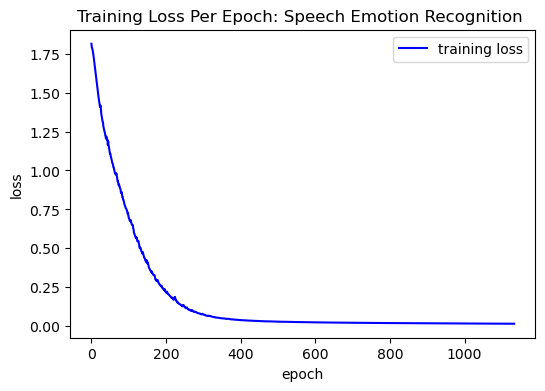

In [15]:
# TO DO: Plot the loss_values per epoch. Appropiately label title, axes and legend 
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6,4))
plt.plot(loss_values, color="blue", label = "training loss")
plt.xlabel('epoch') # x-axis
plt.ylabel('loss') # y-axis

# legend 
plt.legend(loc='upper right')
# title
plt.title('Training Loss Per Epoch: Speech Emotion Recognition ')
# show plot
plt.show()

**11. Model Predictions**

Let’s predict the values for the test set. This gives us y_pred (the predicted emotions for the features in the test set).

In [16]:
# Predict for the test set
y_pred=ser_model.predict(x_test)

**12. Model Performance**

To calculate the accuracy of our model, use the built-in scoring method. If you wish, you can also use the accuracy_score()
function we imported from scikit-learn. Finally, we’ll round the accuracy to 2 decimal places and print it out.

In [17]:
#accuracy of our model
print('test set accuracy: {0:.2f} %'.format(100*ser_model.score(x_test,y_test)))

test set accuracy: 76.04 %


**Print the classification report**

In [18]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       angry       0.84      0.83      0.83        52
        calm       0.78      0.87      0.82        46
     disgust       0.76      0.86      0.81        44
     fearful       0.63      0.73      0.68        49
       happy       0.78      0.69      0.73        45
         sad       0.79      0.60      0.68        52

    accuracy                           0.76       288
   macro avg       0.76      0.76      0.76       288
weighted avg       0.77      0.76      0.76       288



**Plot the confusion matrix**

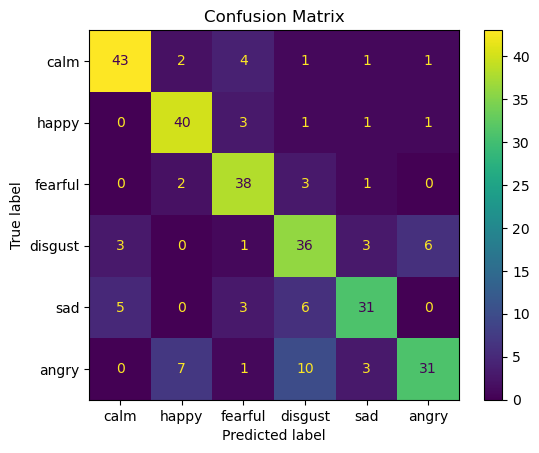

In [19]:
#TO DO-Pretty Plot the Confusion matrix. Use class labels from model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# predict on test set
y_pred = ser_model.predict(x_test)

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# plot confusion matrix 
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=observed_emotions)
disp.plot()
plt.title('Confusion Matrix')
#plt.xticks(rotation=45)
# plt.savefig('images/Confusion_Matrix.png', dpi=300)
plt.show()

**Performance on a single waveform**

In [20]:
print('The predictied emotion from the speech is: {}'.format(ser_model.predict([x_test[22]])[0]))

The predictied emotion from the speech is: fearful


In [21]:
print('The true emotion is: {}'.format(y_test[22]))

The true emotion is: fearful


**13. Pickle (serialize) and save the trained classifier to a fold**

In [22]:
# Serialization with Python's Pickle
import pickle
import os
dest = os.path.join('classifiers', 'pkl_objects')
if not os.path.exists(dest):
 os.makedirs(dest)

pickle.dump(ser_model, open(os.path.join(dest, 'ser_classifier.pkl'), 'wb'), protocol=4)

**14. Load the saved classifier into memory**

In [23]:
# load the saved the trained classifier into memory
import pickle
import re
import os
os.chdir('classifiers')
pickled_ser_model = pickle.load(open(os.path.join('pkl_objects', 'ser_classifier.pkl'), 'rb'))

**15. Test the re-loaded model**

In [24]:
print('The reloaded model predicts the emotion from the speech is:{}'
      .format(pickled_ser_model.predict([x_test[33]])[0]))

The reloaded model predicts the emotion from the speech is:angry


In [25]:
print('The true emotion is: {}'.format(y_test[33]))

The true emotion is: angry


**Summary**

In this Python Machine-Learning, Mini-Project, we built a model that learned to recognize emotions from speech. We used an
MLPClassifier for the neural network and made use of the soundfile library to read the sound file. We also used the librosa library
to extract features from the sound files. We serialized the model and tested the reloaded model on *unseen* data and saw that it
performed well. So, as you should have seen, the model delivered an accuracy of 70-80%, which is not bad for our first attempt at
building a speech emotion recognizer.


In **part II** (see below) , you will create a recording of your own voice expressing one of the emotions you trained your model to


<h3 style="text-align:center; color:orange";> Part II - Record and test your voice! - ALL or NONE (20 points)

**This is going to require some research on your part and is all or no credit!**

*Can you find a way to test the emotion in **your speech** by generating a waveform and passing it into your model's predictor?*

- To get credit for this part you **must:**
    - record your voice waveform expressing one of the emotions in the dictionary
        -  <font style="color:red;"/>when you record your voice, you must record it in mono sampled at 16kHz
    - modify the code so that it learns FIVE of the emotions in the emotions dictionary (currently it is only being trained on four
as indicated in the *observed_emotions* python list)
    - test your waveform using your pickled re-loaded classifier and demostrate that it works.
 

**HINTS:**
1. Create python code to record your voice and save it in a waveform appropiate for classification with your model

2. Use FREE audio recording software like:

    - Audacity – the most popular 100% free open-source DAW software on the planet for many years now.
    - Garageband – the super-cheap, (though not technically free) DAW for Mac OSX, which many folks say is easier to learn than Audacity.
    - Presonus Studio One 3 Prime – the first totally-free DAW based on professional software.
    - Pro Tools First – the newest beginner version of Pro Tools 12.
3. Use your cell phone to record your voice expressing emotion (don't know if m4a, mp3, etc. will work with your model but it
might!)
4. YOU figure out something!

<b/><font style="color:orange;"/> Enter your code in the cell(s) below

In [26]:
import pickle

# Load the saved model
with open('ser_model.pkl', 'rb') as f:
    ser_model_reloaded = pickle.load(f)

# Predict the emotion using the reloaded model
predicted_emotion = ser_model_reloaded.predict([x_test[0]])  
print('The reloaded model predicts the emotion from the speech is: {}'.format(predicted_emotion[0]))


The reloaded model predicts the emotion from the speech is: happy
